# XYZ2 MDR Plotting Notebook

Reload saved simulation data and generate threshold plots.

## Run simulations first (terminal)

Run both simulation sets before using reload/plot cells:

```bash
python scripts/run_sweeps_no_spam.py
python scripts/run_sweeps_with_spam.py
```

In [1]:
from pathlib import Path
import json
import sys

REPO_ROOT = Path('.').resolve()
SRC = REPO_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from xyz2_mdr.mdr_noise_sweep import MdrNoiseSweep


In [2]:
# User config
distances = [3, 5, 7, 9, 11]
results_dir = Path("data/simulation_results")
plots_dir = Path("data/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

noise_models = {
    "z_type": "Z Type",
    "pure_z": "Pure Z",
    "unbiased": "Unbiased",
}

WITH_SPAM_P = 1.339e-3
NO_SPAM_P = 0.0


In [3]:
def _close(a: float, b: float, tol: float = 1e-15) -> bool:
    return abs(float(a) - float(b)) <= tol


def _resolve_result_csv(
    noise_model: str,
    distance: int,
    p_spam: float | None = None,
) -> Path:
    legacy = results_dir / f"results_{noise_model}_d{distance}.csv"
    if legacy.exists() and (p_spam is None or _close(p_spam, 0.0)):
        return legacy

    spec_files = sorted(
        results_dir.glob(f"results_{noise_model}_d{distance}_*.spec.json")
    )

    matches = []
    for spec_path in spec_files:
        spec = json.loads(spec_path.read_text(encoding="utf-8"))
        if p_spam is not None:
            val = float(spec.get("p_spam", -1.0))
            if not _close(val, p_spam):
                continue
        csv_path = spec_path.with_suffix("").with_suffix(".csv")
        if csv_path.exists():
            matches.append(csv_path)

    if not matches:
        msg = f"No saved results for {noise_model}, d={distance}"
        if p_spam is not None:
            msg += f", p_spam={p_spam:g}"
        raise FileNotFoundError(msg)

    matches.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return matches[0]


def _load_sweeps_for_p_spam(p_spam: float) -> dict[str, dict[str, MdrNoiseSweep]]:
    sweeps_by_model: dict[str, dict[str, MdrNoiseSweep]] = {}
    print(f"Reloading saved results for p_spam={p_spam:g}...")

    for noise_model, label in noise_models.items():
        sweeps: dict[str, MdrNoiseSweep] = {}
        for distance in distances:
            try:
                csv_path = _resolve_result_csv(noise_model, distance, p_spam)
                sweeps[f"{label} (d={distance})"] = MdrNoiseSweep(
                    load_data_filename=csv_path
                )
            except FileNotFoundError:
                print(f"Warning: missing {label} data for d={distance}, p_spam={p_spam:g}.")
        sweeps_by_model[noise_model] = sweeps

    return sweeps_by_model


def _plot_threshold_suite(
    sweeps_by_model: dict[str, dict[str, MdrNoiseSweep]],
    output_label: str,
) -> None:
    print(f"Writing threshold plots to {plots_dir.resolve()}")
    for noise_model, label in noise_models.items():
        sweeps = sweeps_by_model[noise_model]
        if not sweeps:
            print(f"Skipping {label}: no matching saved runs were found.")
            continue

        save_path = plots_dir / f"threshold_{noise_model}_{output_label}.pdf"
        MdrNoiseSweep.plot_error_multi(
            sweeps,
            category="logical",
            rounds=[1],
            subset=["Logical X"],
            overlay=False,
            log_x=True,
            save_path=save_path,
        )
        print(f"Saved {save_path.name}")


## Threshold Graphs With SPAM

Use this section to generate threshold plots from the runs saved with the project SPAM setting `p_spam = 1.339e-3`.

Expected outputs:

- `threshold_z_type_with_spam.pdf`
- `threshold_pure_z_with_spam.pdf`
- `threshold_unbiased_with_spam.pdf`


Reloading saved results for p_spam=0.001339...
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d3_pspam1.339e-03_shots3000_reps30_spec-9f1f153c86e2.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d5_pspam1.339e-03_shots3000_reps30_spec-b6fec5101ad6.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d7_pspam1.339e-03_shots3000_reps30_spec-32b9997d26b5.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d9_pspam1.339e-03_shots3000_reps30_spec-c6186e356fe8.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d11_pspam1.339e-03_shots3000_reps30_spec

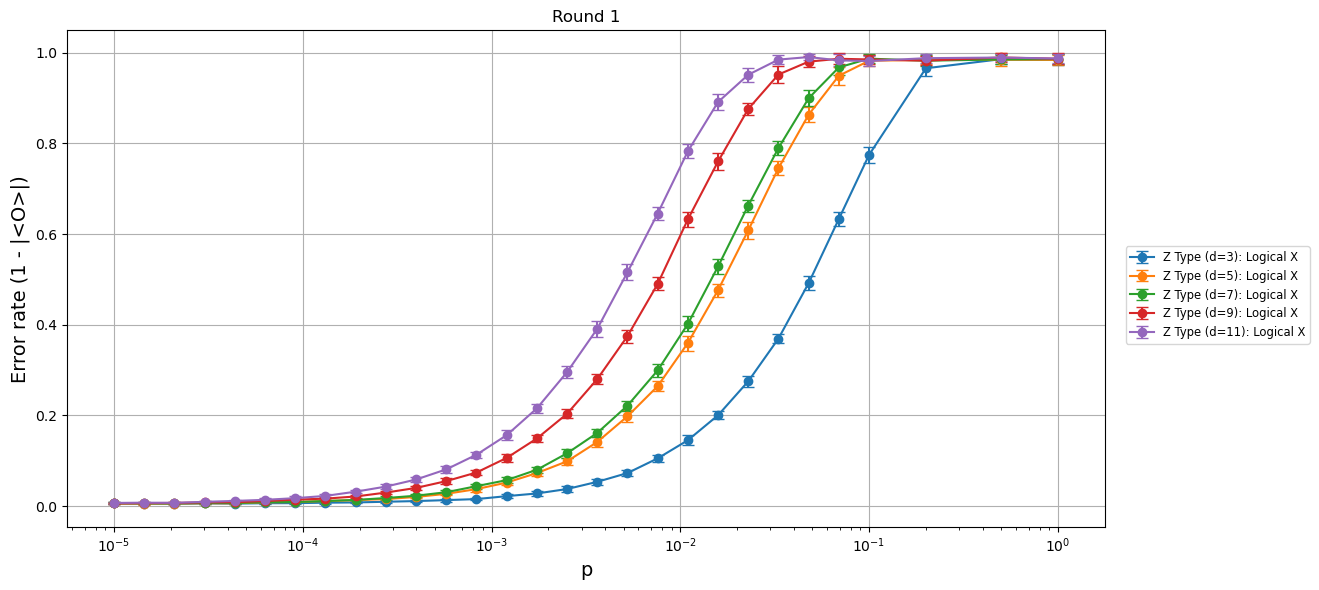

Saved threshold_z_type_with_spam.pdf


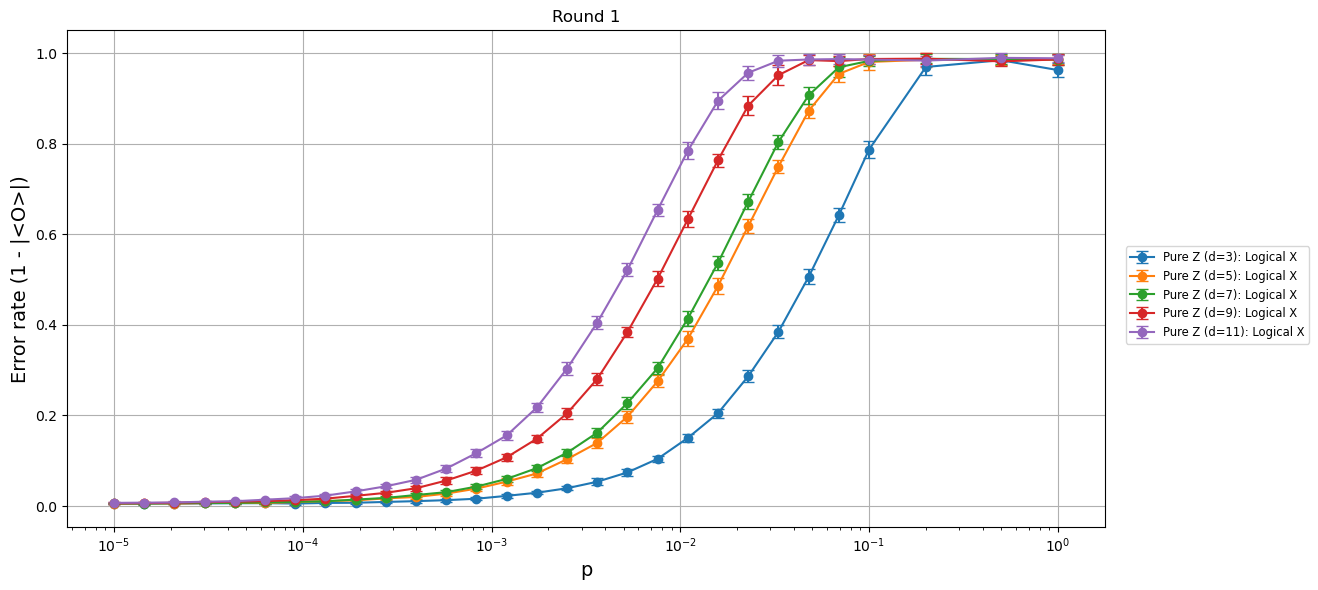

Saved threshold_pure_z_with_spam.pdf


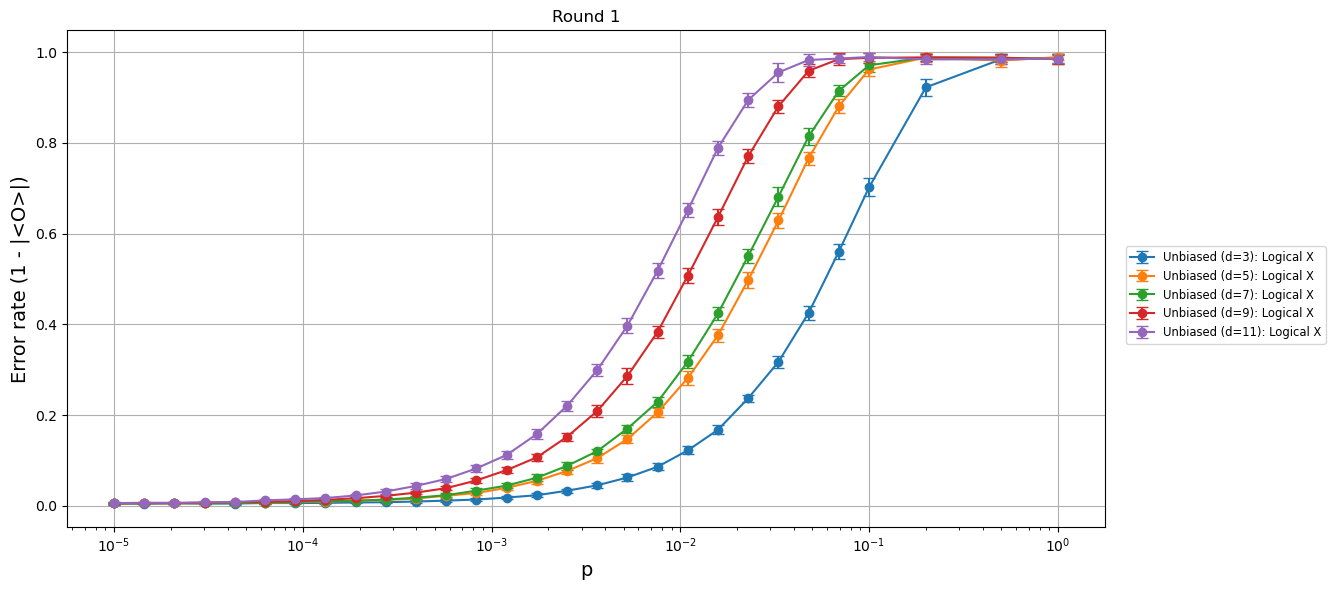

Saved threshold_unbiased_with_spam.pdf


In [4]:
with_spam_sweeps = _load_sweeps_for_p_spam(WITH_SPAM_P)
_plot_threshold_suite(with_spam_sweeps, output_label="with_spam")

## Threshold Graphs Without SPAM

Use this section to generate threshold plots from the no-SPAM runs saved with `p_spam = 0.0`.

Expected outputs:

- `threshold_z_type_no_spam.pdf`
- `threshold_pure_z_no_spam.pdf`
- `threshold_unbiased_no_spam.pdf`


Reloading saved results for p_spam=0...
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d3.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d5.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d7.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d9.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_z_type_d11.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparation/data/simulation_results/results_pure_z_d3.csv
Loaded 29 parameter combinations from /pscratch/sd/s/sohan100/XYZ-2-MDR-Logical-State-Preparati

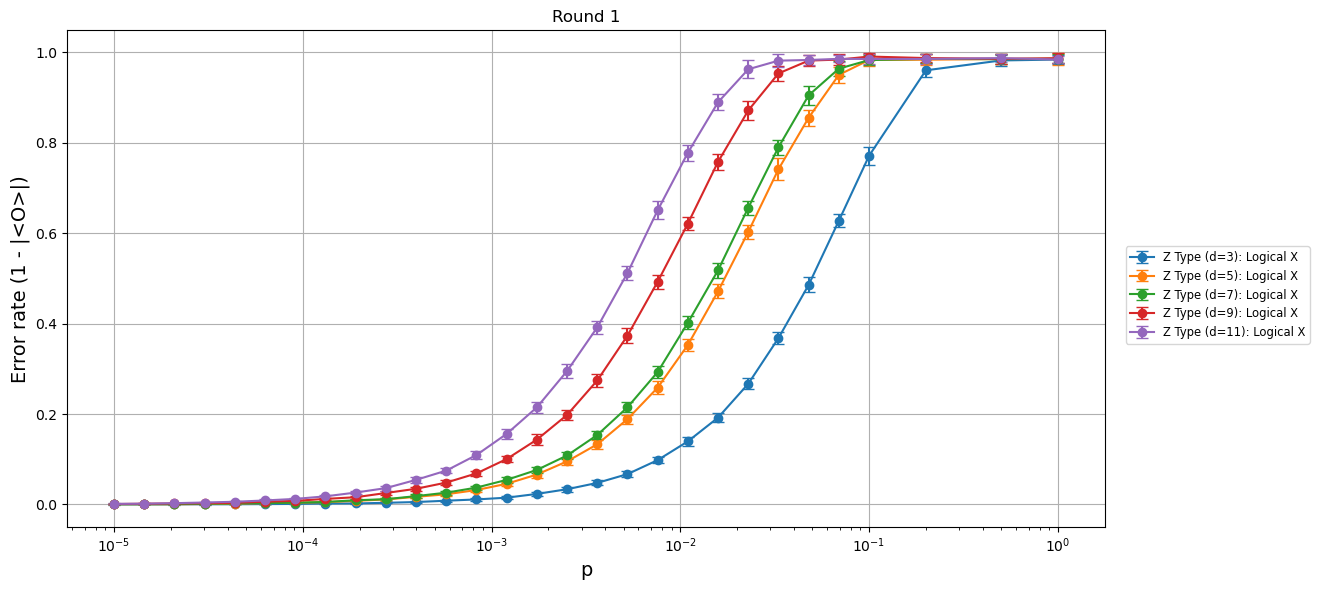

Saved threshold_z_type_no_spam.pdf


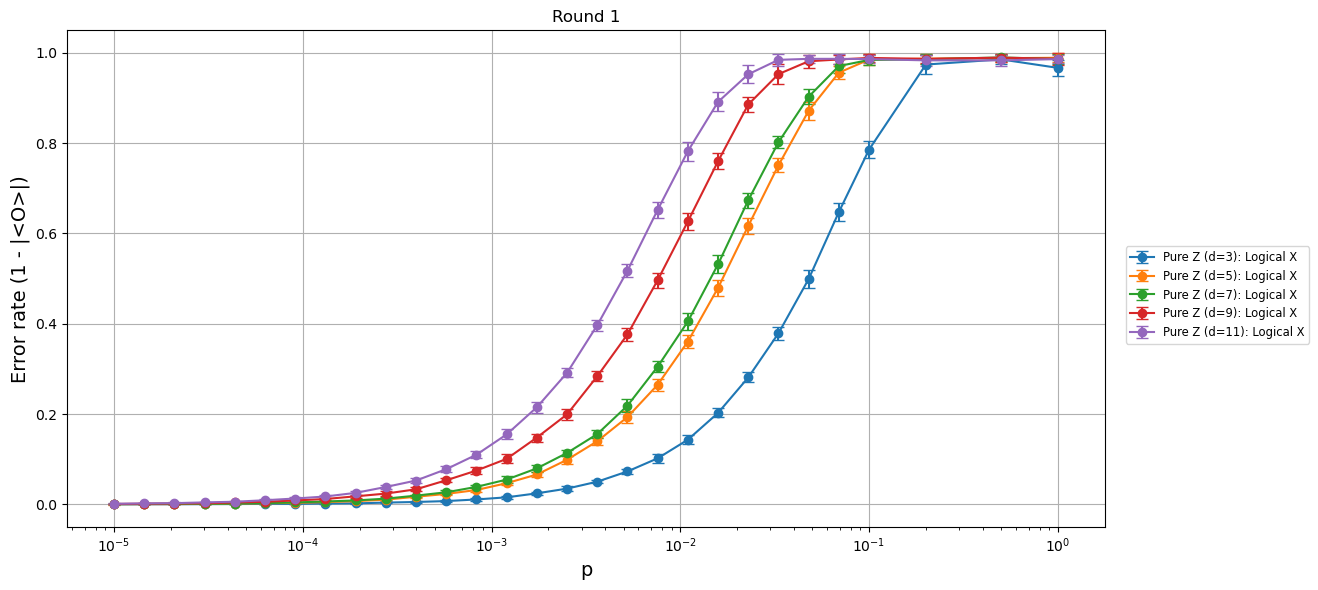

Saved threshold_pure_z_no_spam.pdf


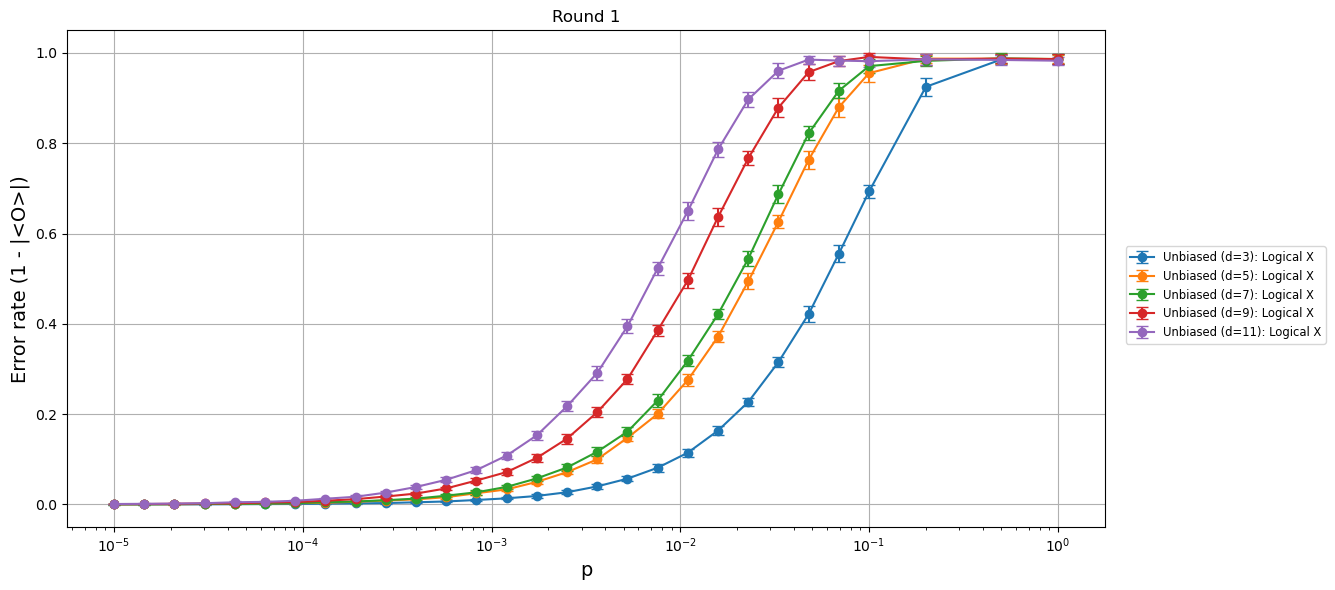

Saved threshold_unbiased_no_spam.pdf


In [5]:
no_spam_sweeps = _load_sweeps_for_p_spam(NO_SPAM_P)
_plot_threshold_suite(no_spam_sweeps, output_label="no_spam")